In [1]:
import pandas as pd
import glob
import sys

dict_samples = { 'PanPan':'Bonobo', 'PanTro':'Chimpanzee', 'hprc':'Human', 
				 'GorGor':'Gorilla', 'PonAbe':'Sorang', 'PonPyg':'Borang' }

def get_matrix(sample):
	df = pd.read_table( f'combined_matrix.t2t_{sample}.tsv', dtype=str )
	df = df.replace({"1.0": "1", "0.0": "0"}) #make sure these are not saved as floats
	return df

def classify_values(s):
	if s != s:  # NaN check
		return 'NaN'
	ones = s.count('1')
	zeros = s.count('0')
	total = ones + zeros
	# Classifications.
	if zeros == 0:
		return 'Fixed' 	# Only 1s
	elif ones == 0:
		return 'Unique to ref' 	# Only 0s
	elif zeros == 1:
		return 'High freq' 	# Mostly 1s and one 0
	elif ones == 1:
		return 'Rare'	# Mostly 0s and one 1
	else:
		return 'Variable' 	# Mix of 1s and 0s
	
def get_species_specific(sample, quiet=False):
	# Get matrix, then species and assembly names.
	df = get_matrix(sample)
	species = dict_samples[sample]
	assembly = df['NUMT_ID'].str.split('_').str[0][0]
	if not quiet:
		print( f"# Number of '{assembly}' NUMTs:", df.shape[0])
		
	# Get the order of T2T columns in this matrix.
	t2t_cols = list(df.columns[1:7])
	if not quiet:
		print( f"# The order of T2T columns is:", t2t_cols)
	
	# Unit test: are these the correct and complete valeus for the T2T columns?
	if set(t2t_cols) != set(dict_samples.values()):
		raise ValueError('\n\t# The T2T species names are inconsistent with the dictionary values.' \
						 '\n\t# Perhaps the T2T columns are not selected properly.')
	
	# Concatenate values for T2T cols.
	df['Label'] = df[t2t_cols].astype(str).agg(''.join, axis=1)

	# Label for species-specific NUMTs (ss).
	label_ss = ''.join([ "1" if x == species else "0" for x in t2t_cols ])
	if not quiet:
		print( f"# The species-specific label for '{assembly}' ({species}) NUMTs is:", label_ss)

	# Use label to SS NUMTs.
	df_ss = df[df['Label']==label_ss]#.drop('Label', axis=1)
	if not quiet:
		print( f"# Number of '{assembly}' NUMTs that are species-specific:", df_ss.shape[0])
		print('\n')
	
	# Get the subset of columns for non-T2T population.
	subset_cols = list( set(df_ss.columns) - set(dict_samples.values()) - set(['NUMT_ID','Label']) )

	# Unit test: are these the correct number of non-T2T sample columns?
	if len(subset_cols) != len(df.columns) - len(t2t_cols) - len(['NUMT_ID', 'Label']):
		# Expected number of columns
		print( len(subset_cols), len(t2t_cols), len(['NUMT_ID', 'Label']), len(df.columns) )
		raise ValueError("\n\t# The number of sample columns is different than expected."\
				   		 f"\n\t# Verify the expression: {len(subset_cols)} + {len(t2t_cols)} + {len(['NUMT_ID', 'Label'])} = {len(df.columns)}")
	
	# Concatenate values for non-T2T population cols.
	df_ss = df_ss.copy()
	df_ss['Values'] = df_ss[subset_cols].astype(str).agg(''.join, axis=1)
	df_ss['Classification'] = df_ss['Values'].apply(classify_values)

	# Prepare output.
	df_ss['Assembly'] = assembly
	df_ss['Species'] = 'S. orangutan' if species == 'Sorang' else 'B. orangutan' if species == 'Borang' else species
	df_ss['Total_samples'] = len(subset_cols) + 1 	# Includes T2T
	df_values = df_ss[['Assembly', 'Species', 'NUMT_ID', 'Label', 'Values', 'Total_samples', 'Classification']]

	return df_values
	

# Run for all species.
list_df = []
for sample in dict_samples.keys():
	# Get SS NUMTs.
	print(f"# Getting species-specific NUMTs for {sample}")
	df = get_species_specific(sample, quiet=True)
	
	list_df.append(df)
df = pd.concat(list_df)

# # Output values.
# file_out = "values.species_specific.tsv"
# df.to_csv( file_out, index=None, sep='\t' )
# print(f"# Succesfully output to {file_out}")

# Create summary of values.
summary = df.groupby('Species')['Classification'].value_counts().reset_index(name='Count')
summary['Total_samples'] = summary['Species'].map(df.groupby('Species')['Total_samples'].first())

# Specify order to match tree.
species_order = list(df['Species'].unique())
summary['Species'] = pd.Categorical(summary['Species'], categories=species_order, ordered=True)
summary = summary.sort_values(['Species', 'Classification']).reset_index(drop=True)

# # Output summary of values.
# file_out = "summary.species_specific.tsv"
# summary.to_csv( file_out, index=None, sep='\t' )
# print(f"# Succesfully output to {file_out}")

summary


# Getting species-specific NUMTs for PanPan
# Getting species-specific NUMTs for PanTro
# Getting species-specific NUMTs for hprc
# Getting species-specific NUMTs for GorGor
# Getting species-specific NUMTs for PonAbe
# Getting species-specific NUMTs for PonPyg


,Species,Classification,Count,Total_samples
0,Bonobo,Fixed,58,7
1,Bonobo,High freq,3,7
2,Bonobo,Variable,4,7
3,Chimpanzee,Fixed,19,21
4,Chimpanzee,High freq,12,21
5,Chimpanzee,Unique to ref,1,21
6,Chimpanzee,Variable,30,21
7,Human,Fixed,127,45
8,Human,Unique to ref,1,45
9,Human,Variable,24,45


Saved: species_specific_pie_charts.pdf, species_specific_pie_charts.png


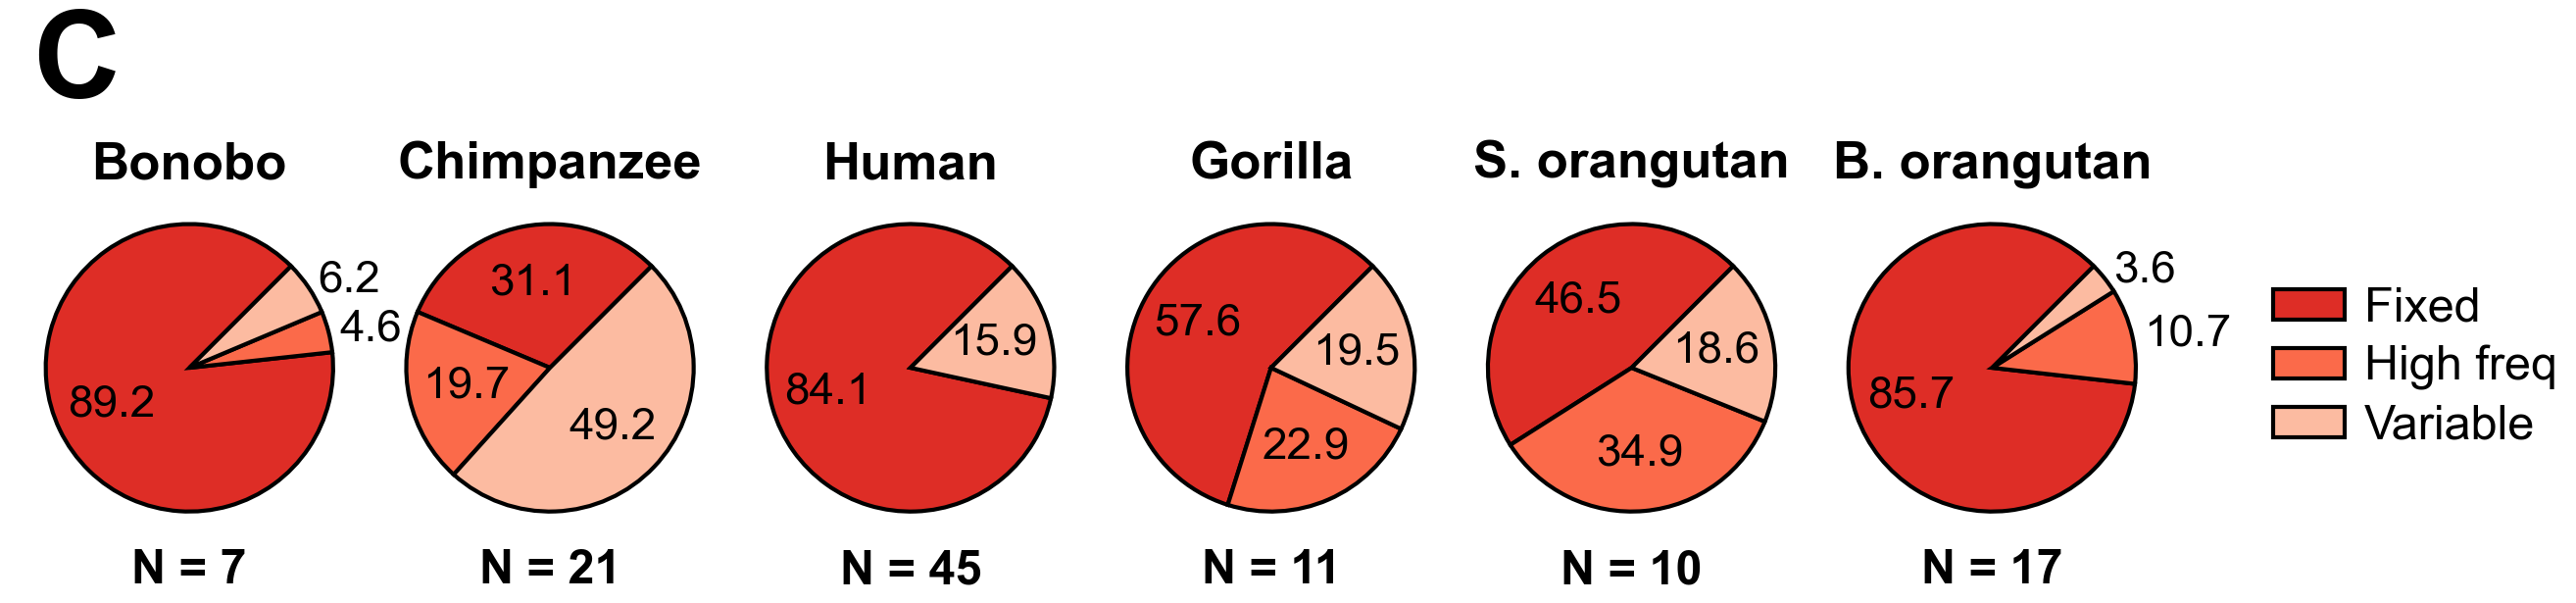

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Filter out "Unique to ref" from summary table
summary = summary[summary["Classification"] != "Unique to ref"]

title_size = 38
n_size = 35
legend_size = n_size
perc_size = n_size -2
c_size = 90

# '#fee0d2','#fc9272','#de2d26']
# ['#fee5d9','#fcbba1','#fc9272','#fb6a4a','#de2d26','#a50f15']
# ['#fee5d9','#fcbba1','#fc9272','#fb6a4a','#ef3b2c','#cb181d','#99000d']
palette = {
	"Fixed": '#de2d26',
	"High freq": "#fb6a4a",
	"Variable": "#fcbba1",
	"Unique to ref": "#fcbba1",
	"Rare": "#fee5d9",
}

assemblies = summary["Species"].unique()
n = len(assemblies)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)
axes = axes[0]
plt.subplots_adjust(wspace=-0.81)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

for ax, assembly in zip(axes, assemblies):
	data = summary[summary["Species"] == assembly].copy()
	colors = data["Classification"].map(palette).fillna("#999999")

	wedges, texts, autotexts = ax.pie(
		data["Count"],
		labels=None,  # Remove labels from pie
		colors=colors,
		autopct="%1.1f%%",
		startangle=45,
		wedgeprops={"edgecolor": "black", "linewidth": 3 },
		textprops={"fontsize": perc_size, "fontweight": False },
	)
	
	# Move small percentage labels apart
	small_labels = [(i, w, t) for i, (w, t) in enumerate(zip(wedges, autotexts))
					if float(t.get_text().replace("%", "")) < 11]

	for j, (_, wedge, autotext) in enumerate(small_labels):
		angle = (wedge.theta1 + wedge.theta2) / 2
		x = np.cos(np.deg2rad(angle))
		y = np.sin(np.deg2rad(angle))

		# spread labels slightly so two small slices have space between them
		y_offset = (j - (len(small_labels) - 1) / 2) * 0.010

		label_r = 1.08
		autotext.set_position((label_r * x, label_r * y + y_offset))
		autotext.set_ha("left" if x >= 0 else "right")
		autotext.set_va("center")
		autotext.set_color("black")
		# autotext.set_fontweight("bold")
	for t in autotexts:
		t.set_text(t.get_text().replace("%", ""))
	ax.set_title(assembly, fontsize=title_size, fontweight="bold")
	ax.text(0.5, -0.1, f"N = {data['Total_samples'].iloc[0]}", transform=ax.transAxes, ha="center", fontsize=n_size, fontweight="bold")

# Add a single legend for all pie charts, but only for classifications that appear
present = set(summary["Classification"].unique())
labels = [label for label in palette.keys() if label in present]

if labels:
	handles = [
		plt.Rectangle((0, 0), 1, 1, facecolor=palette[label], edgecolor="black", linewidth=3.0)
		for label in labels
	]
	fig.legend(
		handles,
		labels,
		loc="center right",
		bbox_to_anchor=(1.01, 0.5),
		frameon=False,
		fontsize=legend_size,
		handlelength=1.5,
		handleheight=0.6,
		handletextpad=0.4,
		borderpad=0.2,
		labelspacing=0.3,
	)

	# Panel label
	fig.text(
		0.14, 1.23, "C",
		ha="left", va="top",
		fontsize=c_size, fontweight="bold"
	)

plt.tight_layout()
out_pdf = "species_specific_pie_charts.pdf"
out_png = "species_specific_pie_charts.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight", dpi=300)
print(f"Saved: {out_pdf}, {out_png}")
plt.show()

In [3]:
df

,Assembly,Species,NUMT_ID,Label,Values,Total_samples,Classification
7,mPanPan1,Bonobo,mPanPan1_numt8,100000,111101,7,High freq
27,mPanPan1,Bonobo,mPanPan1_numt28,100000,111111,7,Fixed
59,mPanPan1,Bonobo,mPanPan1_numt60,100000,111111,7,Fixed
66,mPanPan1,Bonobo,mPanPan1_numt67,100000,111111,7,Fixed
86,mPanPan1,Bonobo,mPanPan1_numt87,100000,111111,7,Fixed
...,...,...,...,...,...,...,...
697,mPonPyg2,B. orangutan,mPonPyg2_numt699,000001,1011111111111111,17,High freq
702,mPonPyg2,B. orangutan,mPonPyg2_numt704,000001,1111111111111111,17,Fixed
730,mPonPyg2,B. orangutan,mPonPyg2_numt732,000001,1111111111111111,17,Fixed
752,mPonPyg2,B. orangutan,mPonPyg2_numt754,000001,1111111111111111,17,Fixed
